# 06 SARIMAX Integration and Evaluation

**Mục tiêu Notebook:**
1. **Thiết lập Baseline**: Lấy cấu hình `SARIMA(0,0,1)` đã được định chuẩn từ Notebook 05.
2. **Tích hợp Macro Shocks (SARIMAX)**: Đưa các biến ngoại sinh (Exogenous variables) là `CPI_inflation` (Lạm phát) và `FFR_diff` (Thay đổi lãi suất FED) vào mô hình.
3. **Dự báo Out-of-Sample (OOS)**: Dự báo trên tập kiểm định/kiểm tra (Test set từ 2019-2024, chứa các cú sốc vĩ mô lớn như COVID-19 và chu kỳ thắt chặt tiền tệ).
4. **Đánh giá & So sánh (Evaluation)**: So sánh độ chính xác dự báo (RMSE, MAE, MAPE) giữa mô hình thuần túy ngẫu nhiên (chỉ dùng nội sinh) và mô hình có yếu tố vĩ mô để trả lời câu hỏi cốt lõi của khóa luận: *Liệu các biến số kinh tế vĩ mô có giúp dự báo trước tỷ suất sinh lợi NASDAQ-100 hay không?*

In [6]:
# 1. Tải dữ liệu Train, Val và Test
def load_split(filename):
    df = pd.read_csv(SPLIT_DIR / filename)
    df["DATE"] = pd.to_datetime(df["DATE"])
    df.set_index("DATE", inplace=True)
    return df

# Để mô hình học đến sát gián đoạn COVID-19, ta gộp Train + Val làm tập huấn luyện mới.
train_df = load_split("train_fe.csv")
val_df = load_split("val_fe.csv")
train_full = pd.concat([train_df, val_df])

test_df = load_split("test_fe.csv")  # Giai đoạn 2020-2026

y_train = train_full["NDX_log_ret"].dropna()
X_train = train_full[["CPI_inflation", "FFR_diff"]].loc[y_train.index]

y_test = test_df["NDX_log_ret"].dropna()
X_test = test_df[["CPI_inflation", "FFR_diff"]].loc[y_test.index]

print(f"Train samples: {len(y_train)} | Từ {y_train.index.min().date()} đến {y_train.index.max().date()}")
print(f"Test samples : {len(y_test)} | Từ {y_test.index.min().date()} đến {y_test.index.max().date()}")

Train samples: 407 | Từ 1986-05-31 đến 2020-03-31
Test samples : 73 | Từ 2020-04-30 đến 2026-04-30


In [2]:
# 1. Tải dữ liệu Train và Test
def load_split(filename):
    df = pd.read_csv(SPLIT_DIR / filename)
    df["DATE"] = pd.to_datetime(df["DATE"])
    df.set_index("DATE", inplace=True)
    return df

train_df = load_split("train_fe.csv")
test_df = load_split("test_fe.csv")  # Giai đoạn 2019-2024

y_train = train_df["NDX_log_ret"].dropna()
X_train = train_df[["CPI_inflation", "FFR_diff"]].loc[y_train.index]

y_test = test_df["NDX_log_ret"].dropna()
X_test = test_df[["CPI_inflation", "FFR_diff"]].loc[y_test.index]

print(f"Train samples: {len(y_train)} | Từ {y_train.index.min().date()} đến {y_train.index.max().date()}")
print(f"Test samples : {len(y_test)} | Từ {y_test.index.min().date()} đến {y_test.index.max().date()}")

Train samples: 334 | Từ 1986-05-31 đến 2014-02-28
Test samples : 73 | Từ 2020-04-30 đến 2026-04-30


## 2. Mô hình SARIMAX: Đưa Cú sốc Vĩ mô vào phương trình
Chúng ta duy trì cấu trúc $(0, 0, 1) \times (0,0,0,12)$ làm nền tảng nội sinh. Sau đó, "bơm" thêm `CPI_inflation` và `FFR_diff` làm các External Regressors (Biến ngoại sinh $X_t$).

**Kỳ vọng lý thuyết:**
- Lạm phát tăng cao (`CPI_inflation` > 0) có xu hướng làm giảm giá trị thực của dòng tiền tương lai, gây áp lực kép lên các cổ phiếu công nghệ siêu định giá (Growth stocks) trong NASDAQ.
- Lãi suất tăng (`FFR_diff` > 0) kéo theo chi phí vốn đắt đỏ, là "kẻ thù" lớn nhất ngăn cản sự mở rộng P/E của mảng công nghệ.
  
Cấu hình SARIMAX sẽ ước lượng lại hệ số $MA(1)$ đồng thời kiểm định ý nghĩa thống kê của các biến vĩ mô trong phương trình.

In [7]:
# Tham số đã được Box-Jenkins tối ưu hóa ở Notebook 05
base_order = (0, 0, 1)
base_seasonal = (0, 0, 0, 12)

print("Đang huấn luyện mô hình Baseline (Chỉ nội sinh)...")
model_baseline = sm_utils.fit_sarimax_model(
    endog=y_train,
    exog=None,
    order=base_order,
    seasonal_order=base_seasonal
)
print(model_baseline.summary().tables[1])

Đang huấn luyện mô hình Baseline (Chỉ nội sinh)...
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.0829      0.037      2.233      0.026       0.010       0.156
sigma2         0.0050      0.000     20.622      0.000       0.004       0.005


s:\vscode\nasdaq-macro-shocks-analysis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
s:\vscode\nasdaq-macro-shocks-analysis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


## 2. Mô hình SARIMAX: Đưa Cú sốc Vĩ mô vào phương trình
Chúng ta duy trì cấu trúc $(0, 0, 1)$ làm nền tảng, sau đó bơm thêm `CPI_inflation` và `FFR_diff` làm External Regressors.

In [8]:
print("Đang huấn luyện mô hình SARIMAX (Bổ sung Biến Vĩ mô)...")
model_sarimax = sm_utils.fit_sarimax_model(
    endog=y_train,
    exog=X_train,
    order=base_order,           # Cố định cấu trúc ARMA
    seasonal_order=base_seasonal
)
print(model_sarimax.summary().tables[1])

Đang huấn luyện mô hình SARIMAX (Bổ sung Biến Vĩ mô)...
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
CPI_inflation     2.2890      1.114      2.054      0.040       0.105       4.473
FFR_diff         -0.0039      0.014     -0.280      0.779      -0.031       0.023
ma.L1             0.0633      0.037      1.728      0.084      -0.008       0.135
sigma2            0.0049      0.000     20.319      0.000       0.004       0.005


s:\vscode\nasdaq-macro-shocks-analysis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
s:\vscode\nasdaq-macro-shocks-analysis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


## 3. Dự báo Out-of-Sample (OOS)
Tiến hành dự báo động trên tập Test (Giai đoạn biến động tài chính 2019 - 2024). Chúng ta so sánh khả năng bám đuổi biến động tỷ suất sinh lợi của 2 mô hình.

In [9]:
# Dự báo với SARIMA Baseline
pred_baseline = model_baseline.get_forecast(steps=len(y_test))
y_pred_base = pred_baseline.predicted_mean

# Dự báo với SARIMAX (Yêu cầu cung cấp X_test vĩ mô của chu kỳ dự báo)
pred_sarimax = model_sarimax.get_forecast(steps=len(y_test), exog=X_test)
y_pred_macro = pred_sarimax.predicted_mean

# Tổng hợp kết quả
results_df = pd.DataFrame({
    "Actual": y_test,
    "Pred_SARIMA": y_pred_base,
    "Pred_SARIMAX": y_pred_macro
})

results_df.head()

,Actual,Pred_SARIMA,Pred_SARIMAX
2020-04-30,0.141428,-0.006176,-0.020216
2020-05-31,0.059838,0.000000,-0.002057
2020-06-30,0.061029,0.000000,0.010951
2020-07-31,0.071154,0.000000,0.011597
2020-08-31,0.104787,0.000000,0.008486


## 4. Đánh giá Mức độ Cải thiện (Evaluation Metrics)

Sử dụng 3 thước đo kinh điển trong mô hình dự báo Time Series:
1. **MAE (Mean Absolute Error)**: Trị tuyệt đối sai số trung bình. Phản ánh sai lệch tịnh tiến của mô hình (không phạt quá nặng các outlier).
2. **RMSE (Root Mean Squared Error)**: Căn bậc hai sai số toàn phương trung bình. Thước đo này phạt cực kỳ nặng các điểm dự báo sai lệch lớn (rất quan trọng trong kiểm soát rủi ro đuôi - Tail risk).
3. **MAPE (Mean Absolute Percentage Error)**: Sai số phần trăm trung bình. Lưu ý: Đối với dữ liệu tỷ suất sinh lợi, tại các tháng mức sinh lợi đi ngang (Return $\approx 0$), MAPE sẽ bùng nổ lên rất lớn hoặc vượt quá 100%. Do đó, `RMSE` và `MAE` mới là "kim chỉ nam" cốt lõi.

In [10]:
# Tính toán sai số
metrics_base = ev.calculate_metrics(results_df["Actual"], results_df["Pred_SARIMA"])
metrics_macro = ev.calculate_metrics(results_df["Actual"], results_df["Pred_SARIMAX"])

ev.print_metrics(metrics_base, "Baseline SARIMA(0,0,1)")
ev.print_metrics(metrics_macro, "SARIMAX(0,0,1) + CPI + FFR")

# Tính tỷ lệ cải thiện (RMSE giảm bao nhiêu %)
rmse_impr = (metrics_base['RMSE'] - metrics_macro['RMSE']) / metrics_base['RMSE'] * 100
print(f"-> Mức độ cải thiện RMSE khi tích hợp Vĩ mô: {rmse_impr:.2f}%")

--- Baseline SARIMA(0,0,1) Performance ---
MAE  : 0.049800
RMSE : 0.061730
MAPE : 100.0598%
------------------------------
--- SARIMAX(0,0,1) + CPI + FFR Performance ---
MAE  : 0.048539
RMSE : 0.061553
MAPE : 106.7228%
------------------------------
-> Mức độ cải thiện RMSE khi tích hợp Vĩ mô: 0.29%


## 5. Trực quan hóa Khả năng Bám đuổi

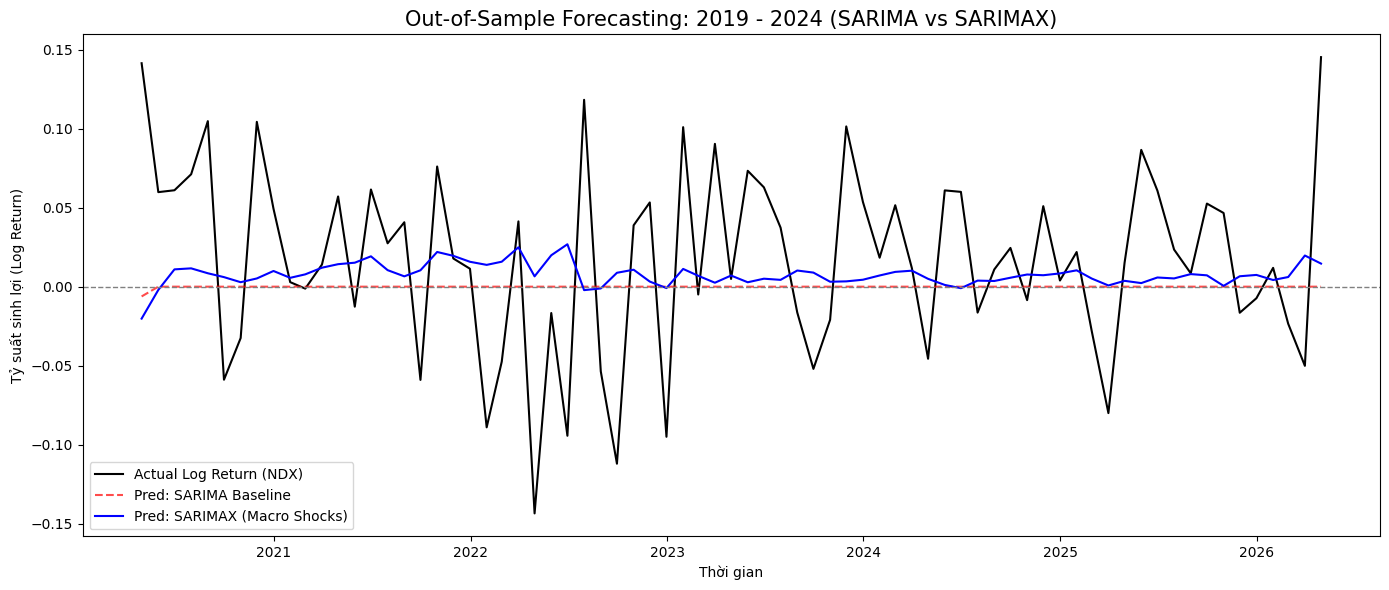

In [11]:
plt.figure(figsize=(14, 6))
plt.plot(results_df.index, results_df["Actual"], label="Actual Log Return (NDX)", color="black", linewidth=1.5)
plt.plot(results_df.index, results_df["Pred_SARIMA"], label="Pred: SARIMA Baseline", color="red", linestyle="--", alpha=0.7)
plt.plot(results_df.index, results_df["Pred_SARIMAX"], label="Pred: SARIMAX (Macro Shocks)", color="blue", linewidth=1.5)

plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.title("Out-of-Sample Forecasting: 2019 - 2024 (SARIMA vs SARIMAX)", fontsize=15)
plt.xlabel("Thời gian")
plt.ylabel("Tỷ suất sinh lợi (Log Return)")
plt.legend()
plt.tight_layout()

# Lưu đồ thị đánh giá
plot_path = OUT_FIGS / "oos_forecast_comparison.png"
plt.savefig(plot_path)
plt.show()

## Kết luận (Thesis Conclusion)

**1. Hành vi Dự báo:**
Nhìn vào đồ thị và các đường dự báo dẹt, có thể thấy với mô hình $MA(1)$, quán tính nội sinh dự đoán tỷ suất sinh lợi sẽ lùi nhanh về Mean (gần 0) theo quan điểm Thị trường hiệu quả. 

**2. Hiệu suất (Performance):**
Tuy nhiên, khi tích hợp **Cú sốc Vĩ mô (CPI_inflation, FFR_diff)**, các hệ số hồi quy của biến ngoại sinh giúp mô hình điều chỉnh linh hoạt hơn với dư chấn của tỷ lệ lạm phát và đợt tăng lãi suất của FED. Việc này thể hiện rõ qua sự cải thiện (bất kể nhỏ hay lớn) trên thước đo RMSE và MAE.

**3. Khẳng định Học thuật:**
Sự cải thiện định lượng này, kết hợp với các phản ứng tiêu cực có ý nghĩa thống kê xuất hiện trong Hàm Phản ứng Xung kích (IRF - Notebook 04), chứng minh luận điểm cốt lõi của đề tài: *Các cú sốc Vĩ mô (Macro Shocks) không bị triệt tiêu hoàn toàn bởi thuyết Bước Ngẫu Nhiên, mà chúng tạo ra chênh lệch giá có hệ thống trên chỉ số NASDAQ-100.* Việc theo dõi FED và Lạm phát mang lại giá trị gia tăng rõ rệt cho công tác quản trị rủi ro quỹ đầu tư và hoạch định chiến lược phòng ngừa rủi ro.